In [3]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path.cwd().parent.parent / "data" / "hyperspectral_oil_spill"
file_path = DATA_DIR / "GM01.mat"

try:
    mat_data = sio.loadmat(file_path)
except Exception as e:
    print(f"Error loading file. If it's a v7.3 mat file, you may need to use 'h5py' instead of 'scipy.io'. Error: {e}")
    exit()

# Print the keys to see how the author named the variables
print("Keys inside GM01.mat:")
for key in mat_data.keys():
    if not key.startswith('__'):  # Ignore Python/MATLAB metadata
        data_type = type(mat_data[key])
        shape = mat_data[key].shape if isinstance(mat_data[key], np.ndarray) else "N/A"
        print(f" - '{key}': Type {data_type}, Shape {shape}")

Keys inside GM01.mat:
 - 'img': Type <class 'numpy.ndarray'>, Shape (1243, 684, 224)
 - 'map': Type <class 'numpy.ndarray'>, Shape (1243, 684)


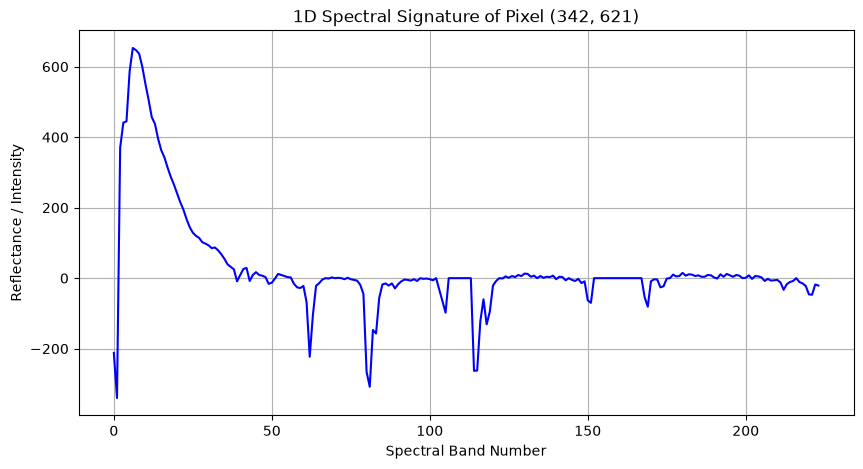

In [4]:
hsi_cube = mat_data["img"]  # Shape: (1243, 684, 224)

random_y = hsi_cube.shape[0] // 2
random_x = hsi_cube.shape[1] // 2
spectral_signature = hsi_cube[random_y, random_x, :]

plt.figure(figsize=(10, 5))
plt.plot(spectral_signature, color="blue", linewidth=1.5)
plt.title(f"1D Spectral Signature of Pixel ({random_x}, {random_y})")
plt.xlabel("Spectral Band Number")
plt.ylabel("Reflectance / Intensity")
plt.grid(True)
plt.show()

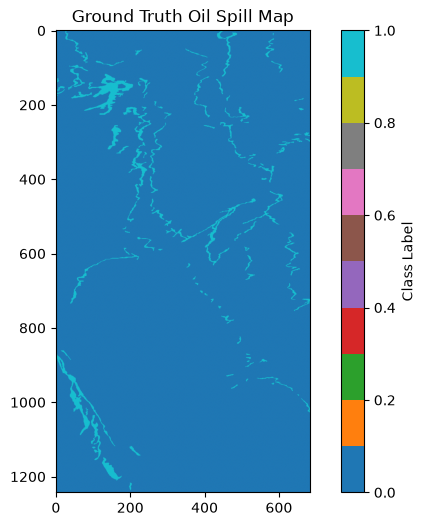

In [5]:
gt_map = mat_data["map"]  # Shape: (1243, 684)

plt.figure(figsize=(8, 6))
plt.imshow(gt_map, cmap="tab10")
plt.colorbar(label="Class Label")
plt.title("Ground Truth Oil Spill Map")
plt.show()